<a href="https://colab.research.google.com/github/mandavitripathi25/Neural-Network-using-MNIST-Data/blob/main/Neural_Network_using_MNIST_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import all the required libraries**

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

**Load the MNIST data**

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print(X_train.shape)
print(X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)
(10000, 28, 28)


**Normalize the Pixel Values**

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0

**Display the sample image**

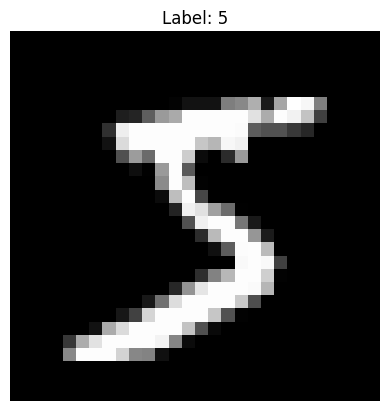

In [5]:
plt.imshow(X_train[0], cmap='gray')
plt.title(f'Label: {y_train[0]}')
plt.axis('off')
plt.show()

**Build the Neural Network**

In [6]:
model = Sequential([
    Flatten(input_shape = (28, 28)), # input layer: converted 28*28 image to 784 features
    Dense(128, activation='relu'), # hidden layer 1
    Dense(64, activation='relu'), # hidden layer 2
    Dense(10, activation='softmax') # output layer: 10 output classes from 0 to 9
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Model Summary**

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

**Model Compilation**

In [8]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

**Model Training**

In [9]:
history = model.fit(
    X_train, y_train, validation_split = 0.2, epochs = 10, batch_size = 32
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9197 - loss: 0.2739 - val_accuracy: 0.9589 - val_loss: 0.1436
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9658 - loss: 0.1144 - val_accuracy: 0.9623 - val_loss: 0.1154
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9764 - loss: 0.0775 - val_accuracy: 0.9682 - val_loss: 0.1103
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9823 - loss: 0.0574 - val_accuracy: 0.9694 - val_loss: 0.1052
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9859 - loss: 0.0449 - val_accuracy: 0.9732 - val_loss: 0.0968
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9885 - loss: 0.0346 - val_accuracy: 0.9726 - val_loss: 0.1033
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9902 - loss: 0.0298 - val_accuracy: 0.9682 - val_loss: 0.1239
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9920 - loss: 0.0239 

**Model Evaluation**

In [10]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(test_loss)
print(test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9799 - loss: 0.0816
0.0816262885928154
0.9799000024795532


**Model Prediction**

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


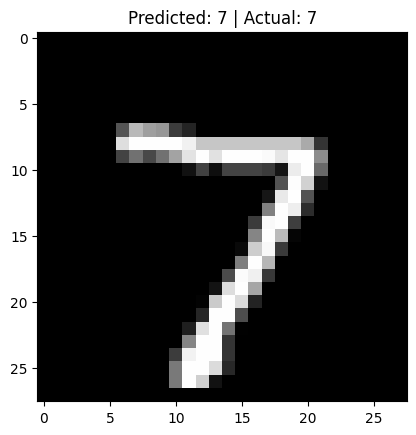

In [11]:
predictions = model.predict(X_test)
predicted_class = tf.argmax(predictions[0]).numpy()

# Display image
plt.imshow(X_test[0], cmap='gray')
plt.title(f'Predicted: {predicted_class} | Actual: {y_test[0]}')
plt.show()

In [12]:
import numpy as np
np.linspace(-10, 10, 100)

array([-10.        ,  -9.7979798 ,  -9.5959596 ,  -9.39393939,
        -9.19191919,  -8.98989899,  -8.78787879,  -8.58585859,
        -8.38383838,  -8.18181818,  -7.97979798,  -7.77777778,
        -7.57575758,  -7.37373737,  -7.17171717,  -6.96969697,
        -6.76767677,  -6.56565657,  -6.36363636,  -6.16161616,
        -5.95959596,  -5.75757576,  -5.55555556,  -5.35353535,
        -5.15151515,  -4.94949495,  -4.74747475,  -4.54545455,
        -4.34343434,  -4.14141414,  -3.93939394,  -3.73737374,
        -3.53535354,  -3.33333333,  -3.13131313,  -2.92929293,
        -2.72727273,  -2.52525253,  -2.32323232,  -2.12121212,
        -1.91919192,  -1.71717172,  -1.51515152,  -1.31313131,
        -1.11111111,  -0.90909091,  -0.70707071,  -0.50505051,
        -0.3030303 ,  -0.1010101 ,   0.1010101 ,   0.3030303 ,
         0.50505051,   0.70707071,   0.90909091,   1.11111111,
         1.31313131,   1.51515152,   1.71717172,   1.91919192,
         2.12121212,   2.32323232,   2.52525253,   2.72

**Activation Functions**

In [13]:
import numpy as np
x = np.linspace(-10, 10, 100)

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def tanh(x):
  return np.tanh(x)

def relu(x):
  return np.maximum(0, x)

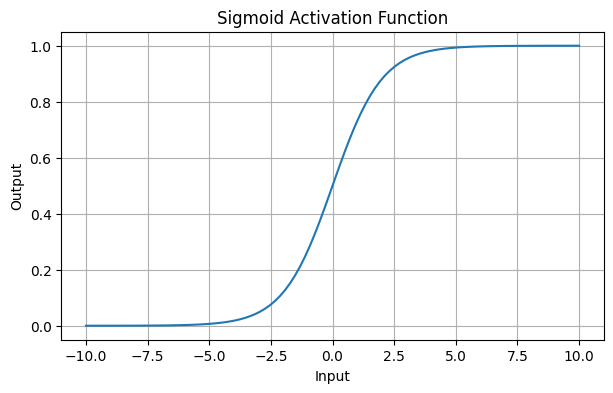

In [14]:
plt.figure(figsize=(7, 4))

plt.plot(x, sigmoid(x))

plt.title("Sigmoid Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")

plt.grid(True)
plt.show()

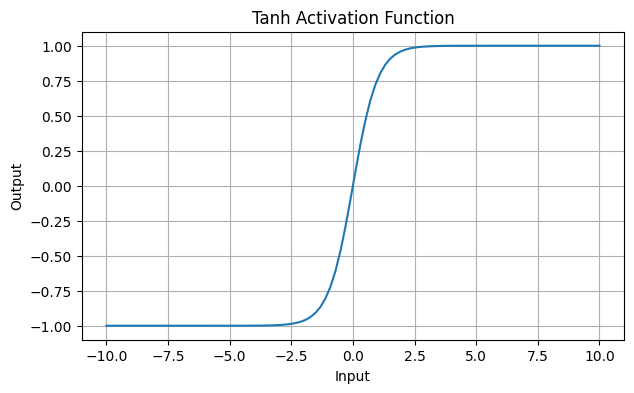

In [15]:
plt.figure(figsize=(7, 4))

plt.plot(x, tanh(x))

plt.title("Tanh Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")

plt.grid(True)
plt.show()

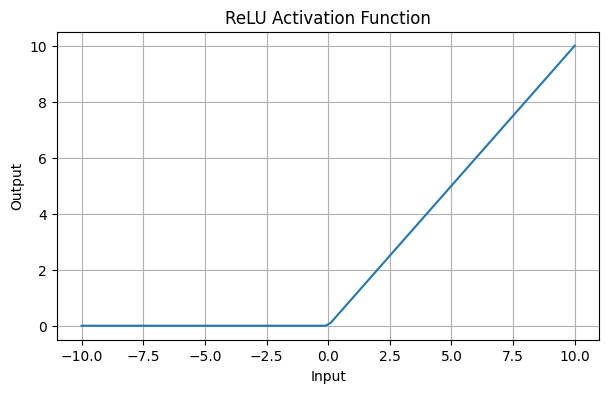

In [16]:
plt.figure(figsize=(7, 4))

plt.plot(x, relu(x))

plt.title("ReLU Activation Function")
plt.xlabel("Input")
plt.ylabel("Output")

plt.grid(True)
plt.show()